# Notebook 08 · Demografía, mercado laboral y capital humano en Iberia

En este notebook trabajamos con la parte demográfica y de capital humano del proyecto.

Usamos cinco indicadores: población total, población en edad laboral, densidad de población, desempleo y formación terciaria. Comparamos las 22 regiones NUTS 2 de España y Portugal y dejamos Andorra como territorio complementario.

Buscamos conocer mejor el contexto laboral de cada territorio y su posible relación con los CPD.

Estos indicadores sirven como aproximación, pero no permiten saber cuántos profesionales especializados en redes, mantenimiento, climatización o seguridad están disponibles en cada región.

Los resultados quedan preparados para el Notebook 10.

In [1]:
# instalamos librerias
%pip install -q pyogrio openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# imports y datos 
import json
import time
import zipfile
import base64
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely.geometry import Point

NOMBRE_NOTEBOOK = "08 - Demografía, mercado laboral y capital humano"
NOMBRE_BLOQUE = "08_demografia_laboral_capital_humano_iberia"

AMBITO_ESTUDIO = (
    "España peninsular, Portugal continental y Andorra"
)

ahora = datetime.now()

FECHA_DESCARGA = ahora.strftime("%Y-%m-%d")
FECHA_EJECUCION = ahora.strftime("%Y-%m-%d %H:%M:%S")

CRS_GEOGRAFICO = "EPSG:4326"
CRS_EUROPEO_AREA = "EPSG:3035"

INPUT_DIR = Path("/kaggle/input")
BASE_DIR = Path("/kaggle/working") / NOMBRE_BLOQUE

print("Notebook:", NOMBRE_NOTEBOOK)
print("Ámbito:", AMBITO_ESTUDIO)

Notebook: 08 - Demografía, mercado laboral y capital humano
Ámbito: España peninsular, Portugal continental y Andorra


In [3]:
# carpetas de trabajo
RAW_DIR = BASE_DIR / "raw"
RAW_EUROSTAT_DIR = RAW_DIR / "eurostat"
RAW_WORLD_BANK_DIR = RAW_DIR / "world_bank"
RAW_GEOMETRIAS_DIR = RAW_DIR / "geometrias"

PROCESSED_DIR = BASE_DIR / "processed"
GPKG_DIR = PROCESSED_DIR / "geopackage"

TABLAS_DIR = BASE_DIR / "tablas"
FIGURAS_DIR = BASE_DIR / "figuras"
DASHBOARD_DIR = BASE_DIR / "dashboard"
LOGS_DIR = BASE_DIR / "logs"
MANIFEST_DIR = BASE_DIR / "manifest"

carpetas = [
    RAW_EUROSTAT_DIR,
    RAW_WORLD_BANK_DIR,
    RAW_GEOMETRIAS_DIR,
    GPKG_DIR,
    TABLAS_DIR,
    FIGURAS_DIR,
    DASHBOARD_DIR,
    LOGS_DIR,
    MANIFEST_DIR
]

for carpeta in carpetas:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )

configuracion_08 = {
    "notebook": NOMBRE_NOTEBOOK,
    "bloque": NOMBRE_BLOQUE,
    "ambito": AMBITO_ESTUDIO,
    "fecha_descarga": FECHA_DESCARGA,
    "fecha_ejecucion": FECHA_EJECUCION,
    "crs_geografico": CRS_GEOGRAFICO,
    "crs_europeo_area": CRS_EUROPEO_AREA,
    "base_dir": str(BASE_DIR)
}

ruta_configuracion_08 = (
    MANIFEST_DIR
    / "configuracion_inicial_notebook_08.csv"
)

pd.DataFrame(
    [configuracion_08]
).to_csv(
    ruta_configuracion_08,
    index=False,
    encoding="utf-8-sig"
)

print("Carpeta de trabajo:", BASE_DIR)


Carpeta de trabajo: /kaggle/working/08_demografia_laboral_capital_humano_iberia


In [4]:
# datos de Kaggle 
import shutil

json_preparados_08 = list(
    INPUT_DIR.rglob("*.json")
)
json_eurostat_08 = []
json_world_bank_08 = []

for archivo in json_preparados_08:
    nombre = archivo.name.lower()

    if nombre.startswith("eurostat_"):
        json_eurostat_08.append(archivo)
    elif nombre.startswith("andorra_"):
        json_world_bank_08.append(archivo)

DATOS_PREPARADOS_08 = (
    len(json_eurostat_08) > 0
    and len(json_world_bank_08) > 0
)

if DATOS_PREPARADOS_08:
    for origen in json_eurostat_08:
        destino = RAW_EUROSTAT_DIR / origen.name
        shutil.copy2(origen, destino)
    for origen in json_world_bank_08:
        destino = RAW_WORLD_BANK_DIR / origen.name
        shutil.copy2(origen, destino)
    print("Datos preparados encontrados.")
    print("Eurostat:", len(json_eurostat_08))
    print("World Bank:", len(json_world_bank_08))
else:
    print("No están todos los JSON preparados.")
    print("Continuamos con las APIs.")

No están todos los JSON preparados.
Continuamos con las APIs.


## Fuentes y criterio temporal

Para este bloque usamos Eurostat y Banco Mundial.

Los datos de España y Portugal están a escala NUTS 2. Andorra la tratamos aparte, a escala nacional, porque no tiene una división territorial equivalente.

Trabajamos con 22 regiones comparables de España y Portugal. Andorra la mantenemis como territorio complementario y no entra en el ranking.

Para cada indicador usamos el dato más reciente disponible y guardamos también su año de referencia, ya que no todos corresponden al mismo periodo.

Estos datos nos ayudan a comparar población, mercado laboral y formación entre territorios, aunque no permiten saber directamente cuántos profesionales especializados en centros de datos hay disponibles.


In [5]:
# fuentes y trazabilidad

EUROSTAT_BASE_URL_08 = (
    "https://ec.europa.eu/eurostat/api/"
    "dissemination/statistics/1.0/data"
)

ANIOS_CANDIDATOS = [
    2024, 2023, 2022, 2021, 2020
]
PAISES_EUROSTAT_08 = [
    "ES",
    "PT"
]
PAIS_ANDORRA_WB_08 = "AD"

CODIGOS_NUTS_EXCLUIDOS_MODELO_08 = [
    "ES53",  # Illes Balears
    "ES63",  # Ceuta
    "ES64",  # Melilla
    "ES70",  # Canarias
    "PT20",  # Açores
    "PT30"   # Madeira
]

df_fuentes_08 = pd.DataFrame({
    "fuente": [
        "Eurostat",
        "World Bank"
    ],
    "territorio": [
        "España y Portugal",
        "Andorra"
    ],
    "escala": [
        "NUTS 2",
        "Nacional"
    ]
})
df_catalogo_indicadores_08 = pd.DataFrame({
    "indicador": [
        "poblacion_total",
        "poblacion_edad_laboral",
        "densidad_poblacion",
        "tasa_desempleo",
        "nivel_formativo_terciario"
    ],
    "descripcion": [
        "Población total",
        "Población entre 15 y 64 años",
        "Habitantes por km²",
        "Porcentaje de desempleo",
        "Población con formación terciaria"
    ]
})
df_decisiones_metodologicas_08 = pd.DataFrame({
    "decision": [
        "Territorios comparables",
        "Andorra",
        "Periodo"
    ],
    "criterio": [
        "22 regiones NUTS 2",
        "Unidad nacional complementaria",
        "Dato más reciente entre 2020 y 2024"
    ]
})

tablas_trazabilidad_08 = {
    "fuentes_trazabilidad_notebook_08.csv":
        df_fuentes_08,
    "catalogo_indicadores_notebook_08.csv":
        df_catalogo_indicadores_08,
    "decisiones_metodologicas_notebook_08.csv":
        df_decisiones_metodologicas_08
}

for nombre, tabla in tablas_trazabilidad_08.items():
    for carpeta in [TABLAS_DIR, MANIFEST_DIR]:
        tabla.to_csv(
            carpeta / nombre,
            index=False,
            encoding="utf-8-sig"
        )
df_resumen_02a = pd.DataFrame([{
    "fuentes": len(df_fuentes_08),
    "indicadores": len(df_catalogo_indicadores_08),
    "territorios_comparables": 22,
    "andorra_complementaria": True,
    "estado": "correcto"
}])

ruta_resumen_02a = (
    MANIFEST_DIR
    / "CIERRE_02A_fuentes_trazabilidad_notebook_08.csv"
)
df_resumen_02a.to_csv(
    ruta_resumen_02a,
    index=False,
    encoding="utf-8-sig"
)

print("Fuentes:", len(df_fuentes_08))
print("Indicadores:", len(df_catalogo_indicadores_08))
print("Territorios comparables: 22")
print("Andorra: unidad complementaria")
print("Trazabilidad 02A: correcta")

Fuentes: 2
Indicadores: 5
Territorios comparables: 22
Andorra: unidad complementaria
Trazabilidad 02A: correcta


In [6]:
# funciones de descarga
def guardar_json(datos, ruta):
    ruta = Path(ruta)
    with open(ruta, "w", encoding="utf-8") as archivo:
        json.dump(
            datos,
            archivo,
            ensure_ascii=False,
            indent=2
        )
    return ruta

def descargar_json_api(
    nombre_consulta,
    url,
    params,
    ruta_salida,
    timeout=90
):
    log = {
        "nombre_consulta": nombre_consulta,
        "status_code": None,
        "descarga_correcta": False,
        "error": None
    }
    try:
        respuesta = requests.get(
            url,
            params=params,
            timeout=timeout
        )
        log["status_code"] = respuesta.status_code

        if respuesta.status_code != 200:
            log["error"] = f"HTTP_{respuesta.status_code}"
            return None, log

        datos = respuesta.json()
        guardar_json(datos, ruta_salida)

        log["descarga_correcta"] = True
        return datos, log

    except Exception as error:
        log["error"] = str(error)
        return None, log

def descargar_world_bank_indicador(
    pais_iso3,
    codigo_indicador,
    nombre_indicador,
    ruta_salida_json
):
    url = (
        f"https://api.worldbank.org/v2/country/{pais_iso3}"
        f"/indicator/{codigo_indicador}"
    )
    datos, log = descargar_json_api(
        nombre_consulta=nombre_indicador,
        url=url,
        params={
            "format": "json",
            "per_page": 20000
        },
        ruta_salida=ruta_salida_json
    )

    filas = []

    if isinstance(datos, list) and len(datos) > 1 and datos[1]:
        for registro in datos[1]:
            filas.append({
                "pais": pais_iso3,
                "indicador": codigo_indicador,
                "nombre_indicador": nombre_indicador,
                "anio": registro.get("date"),
                "valor": registro.get("value")
            })

    return pd.DataFrame(filas), log

In [7]:
# convertir JSON de Eurostat a tabla
def convertir_eurostat_json_a_dataframe(
    datos_json,
    nombre_valor="valor"
):
    necesarias = {"id", "size", "dimension", "value"}

    if not datos_json or not necesarias.issubset(datos_json):
        return pd.DataFrame()
    dimensiones = datos_json["id"]
    forma = tuple(datos_json["size"])
    categorias = {}

    for dimension in dimensiones:
        indices = (
            datos_json["dimension"][dimension]
            ["category"]["index"]
        )
        if isinstance(indices, dict):
            categorias[dimension] = {
                int(posicion): codigo
                for codigo, posicion in indices.items()
            }
        else:
            categorias[dimension] = dict(
                enumerate(indices)
            )
    valores = datos_json["value"]

    if isinstance(valores, dict):
        valores = valores.items()
    else:
        valores = enumerate(valores)

    filas = []

    for indice, valor in valores:
        if valor is None:
            continue
        posiciones = np.unravel_index(
            int(indice),
            forma
        )
        fila = {}

        for dimension, posicion in zip(
            dimensiones,
            posiciones
        ):
            fila[dimension] = categorias[
                dimension
            ].get(int(posicion))

        fila[nombre_valor] = valor
        filas.append(fila)

    return pd.DataFrame(filas)

In [8]:
# selección temporal y normalización
def seleccionar_anio_mas_reciente(
    df,
    columna_territorio,
    columna_anio,
    columna_valor,
    anios_candidatos
):
    if df.empty:
        return pd.DataFrame()

    datos = df.copy()
    datos[columna_anio] = pd.to_numeric(
        datos[columna_anio],
        errors="coerce"
    )
    datos[columna_valor] = pd.to_numeric(
        datos[columna_valor],
        errors="coerce"
    )
    datos = datos.dropna(
        subset=[
            columna_territorio,
            columna_anio,
            columna_valor
        ]
    )
    datos = datos[
        datos[columna_anio].isin(anios_candidatos)
    ]
    datos = datos.sort_values(
        [columna_territorio, columna_anio],
        ascending=[True, False]
    )
    datos = datos.drop_duplicates(
        columna_territorio
    )
    return datos.reset_index(drop=True)

def normalizar_minmax(serie, invertir=False):
    valores = pd.to_numeric(
        serie,
        errors="coerce"
    )

    minimo = valores.min()
    maximo = valores.max()

    if pd.isna(minimo) or pd.isna(maximo):
        return valores
    if minimo == maximo:
        return pd.Series(
            0.5,
            index=serie.index
        )
    valores = (
        (valores - minimo)
        / (maximo - minimo)
    )
    if invertir:
        valores = 1 - valores

    return valores

In [9]:
# guardamos las funciones usadas
funciones_03a = [
    "guardar_json",
    "descargar_json_api",
    "descargar_world_bank_indicador",
    "convertir_eurostat_json_a_dataframe",
    "seleccionar_anio_mas_reciente",
    "normalizar_minmax"
]
ruta_funciones = (
    MANIFEST_DIR
    / "CIERRE_03A_funciones_auxiliares_notebook_08.csv"
)
pd.Series(
    funciones_03a,
    name="funcion"
).to_csv(
    ruta_funciones,
    index=False,
    encoding="utf-8-sig"
)
print("Funciones auxiliares:", len(funciones_03a))

Funciones auxiliares: 6


In [10]:
# filtro NUTS 2 de España y Portugal

def filtrar_nuts2(df):
    if df is None or df.empty or "geo" not in df.columns:
        return pd.DataFrame()

    datos = df.copy()
    codigos = datos["geo"].astype(str)
    excluir = [
        "ES53", "ES63", "ES64", "ES70",
        "PT16", "PT17", "PT18",
        "PT20", "PT30"
    ]
    filtro = (
        codigos.str.len().eq(4)
        & codigos.str.startswith(("ES", "PT"))
        & ~codigos.isin(excluir)
    )
    return datos.loc[filtro].reset_index(drop=True)

In [11]:
# indicadores de Eurostat
base = {
    "lang": "en",
    "geoLevel": "nuts2",
    "time": ANIOS_CANDIDATOS
}
paro = {
    **base,
    "sex": "T",
    "age": "Y15-74"
}
formacion = {
    **base,
    "sex": "T",
    "age": "Y25-64"
}

catalogo_04a = [
    {
        "indicador": "poblacion_total",
        "dataset": "demo_r_pjanaggr3",
        "candidatos": [
            {**base, "unit": "NR", "sex": "T", "age": "TOTAL"}
        ]
    },
    {
        "indicador": "poblacion_edad_laboral",
        "dataset": "demo_r_pjanaggr3",
        "candidatos": [
            {**base, "unit": "NR", "sex": "T", "age": "Y15-64"},
            {**base, "unit": "NR", "sex": "T", "age": "Y15-74"}
        ]
    },
    {
        "indicador": "densidad_poblacion",
        "dataset": "demo_r_d3dens",
        "candidatos": [
            base.copy()
        ]
    },
    {
        "indicador": "tasa_desempleo",
        "dataset": "lfst_r_lfu3rt",
        "candidatos": [
            {**paro, "unit": "PC", "isced11": "TOTAL"},
            {**paro, "unit": "PC_ACT", "isced11": "TOTAL"},
            {**paro, "isced11": "TOTAL"},
            paro.copy()
        ]
    },
    {
        "indicador": "nivel_formativo_terciario",
        "dataset": "edat_lfse_04",
        "candidatos": [
            {**formacion, "unit": "PC", "isced11": "ED5-8"},
            {**formacion, "unit": "PC", "isced11": "ED5_8"},
            {**formacion, "isced11": "ED5-8"},
            {**formacion, "isced11": "ED5_8"}
        ]
    }
]

print("Indicadores Eurostat:", len(catalogo_04a))

Indicadores Eurostat: 5


In [12]:
# carga de un candidato Eurostat
def cargar_candidato(indicador, dataset, numero, parametros):
    nombre = (
        f"{indicador}_{dataset}_candidato_{numero}.json"
    )
    ruta_salida = RAW_EUROSTAT_DIR / nombre

    # primero buscamos el JSON en Input
    rutas_input = list(
        INPUT_DIR.rglob(nombre)
    )
    if rutas_input:
        with open(
            rutas_input[0],
            encoding="utf-8"
        ) as archivo:
            datos = json.load(archivo)
        log = {
            "indicador": indicador,
            "candidato": numero,
            "origen": "Kaggle Input",
            "status_code": None,
            "error": None
        }

    else:
        # si no lo esta, consultamos Eurostat
        datos, log = descargar_json_api(
            f"eurostat_{indicador}_{numero}",
            f"{EUROSTAT_BASE_URL_08}/{dataset}",
            parametros,
            ruta_salida,
            timeout=180
        )
        log["origen"] = "API"
    df = convertir_eurostat_json_a_dataframe(datos)
    df = filtrar_nuts2(df)

    log["filas"] = len(df)

    return df, log

In [13]:
# probamos los candidatos de cada indicador
completos = []
recientes = []
logs_04a = []
resumen_04a = []

for item in catalogo_04a:
    indicador = item["indicador"]
    dataset = item["dataset"]

    candidato_valido = None
    territorios = 0

    for numero, parametros in enumerate(item["candidatos"], 1):
        df, log = cargar_candidato(
            indicador,
            dataset,
            numero,
            parametros
        )
        logs_04a.append(log)

        if df.empty:
            continue
        df["indicador_modelo"] = indicador
        df["fuente"] = "Eurostat"
        df["numero_candidato"] = numero

        reciente = seleccionar_anio_mas_reciente(
            df,
            "geo",
            "time",
            "valor",
            ANIOS_CANDIDATOS
        )

        if reciente.empty:
            continue
        completos.append(df)
        recientes.append(reciente)
        candidato_valido = numero
        territorios = reciente["geo"].nunique()
        break

    resumen_04a.append({
        "indicador": indicador,
        "dataset": dataset,
        "candidato": candidato_valido,
        "territorios": territorios
    })

    print(indicador, ":", territorios, "territorios")

poblacion_total : 22 territorios
poblacion_edad_laboral : 22 territorios
densidad_poblacion : 22 territorios
tasa_desempleo : 22 territorios
nivel_formativo_terciario : 22 territorios


In [14]:
# unimos los resultados de Eurostat
df_eurostat_completo_04a = pd.concat(
    completos,
    ignore_index=True
)
df_eurostat_reciente_04a = pd.concat(
    recientes,
    ignore_index=True
)
df_log_eurostat_04a = pd.DataFrame(logs_04a)
df_resumen_indicadores_04a = pd.DataFrame(resumen_04a)

print("Filas completas:", len(df_eurostat_completo_04a))
print("Filas recientes:", len(df_eurostat_reciente_04a))
print(
    "Territorios:",
    df_eurostat_reciente_04a["geo"].nunique()
)
print(
    "Indicadores:",
    df_eurostat_reciente_04a["indicador_modelo"].nunique()
)

Filas completas: 535
Filas recientes: 110
Territorios: 22
Indicadores: 5


In [15]:
# cobertura Eurostat
indicadores_04b = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario"
]
datos_04b = df_eurostat_reciente_04a.copy()
datos_04b["valor"] = pd.to_numeric(
    datos_04b["valor"],
    errors="coerce"
)

# una fila por territorio y una columna por indicador
valores_04b = datos_04b.pivot(
    index="geo",
    columns="indicador_modelo",
    values="valor"
)
valores_04b = valores_04b[
    indicadores_04b
]

# años de referencia
anios_04b = datos_04b.pivot(
    index="geo",
    columns="indicador_modelo",
    values="time"
)
anios_04b = anios_04b[
    indicadores_04b
].add_prefix("anio_")

# comprobamos cuántos indicadores tiene cada territorio
df_cobertura_04b = (
    valores_04b
    .notna()
    .sum(axis=1)
    .rename("indicadores_disponibles")
    .reset_index()
)
df_cobertura_04b["cobertura_completa"] = (
    df_cobertura_04b["indicadores_disponibles"] == 5
)
df_cobertura_04b["pais"] = (
    df_cobertura_04b["geo"].str[:2]
)
geos_comparables_04b = df_cobertura_04b.loc[
    df_cobertura_04b["cobertura_completa"],
    "geo"
].tolist()
geos_incompletos_04b = df_cobertura_04b.loc[
    ~df_cobertura_04b["cobertura_completa"],
    "geo"
].tolist()

# tabla final de los territorios 
df_eurostat_modelo_comparable_04b = pd.concat(
    [valores_04b, anios_04b],
    axis=1
)
df_eurostat_modelo_comparable_04b = (
    df_eurostat_modelo_comparable_04b
    .loc[geos_comparables_04b]
    .reset_index()
)
df_eurostat_modelo_comparable_04b["pais"] = (
    df_eurostat_modelo_comparable_04b["geo"].str[:2]
)
df_eurostat_modelo_comparable_04b[
    "tipo_territorio"
] = "NUTS2_comparable"
df_eurostat_modelo_comparable_04b[
    "fuente"
] = "Eurostat"

# comprobamos si falta algún indicador
df_faltantes_04b = (
    valores_04b
    .isna()
    .reset_index()
    .melt(
        id_vars="geo",
        var_name="indicador_faltante",
        value_name="falta"
    )
)
df_faltantes_04b = df_faltantes_04b[
    df_faltantes_04b["falta"]
].drop(columns="falta")
df_faltantes_04b["pais"] = (
    df_faltantes_04b["geo"].str[:2]
)

# guardamos las tablas
df_cobertura_04b.to_csv(
    TABLAS_DIR / "control_cobertura_eurostat_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_faltantes_04b.to_csv(
    TABLAS_DIR / "indicadores_faltantes_eurostat_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_eurostat_modelo_comparable_04b.to_csv(
    TABLAS_DIR / "eurostat_modelo_nuts2_comparable_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
estado_04b = (
    "correcto"
    if len(geos_comparables_04b) == 22
    else "revisar"
)
pd.DataFrame([{
    "territorios_detectados": len(df_cobertura_04b),
    "territorios_comparables": len(geos_comparables_04b),
    "territorios_incompletos": len(geos_incompletos_04b),
    "estado": estado_04b
}]).to_csv(
    MANIFEST_DIR / "CIERRE_04B_cobertura_eurostat.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios detectados:", len(df_cobertura_04b))
print("Territorios comparables:", len(geos_comparables_04b))
print("Territorios incompletos:", len(geos_incompletos_04b))
print("Estado 04B:", estado_04b)

Territorios detectados: 22
Territorios comparables: 22
Territorios incompletos: 0
Estado 04B: correcto


In [16]:
# indicadores de Andorra

catalogo_05a = {
    "poblacion_total": [
        "SP.POP.TOTL"
    ],
    "poblacion_edad_laboral": [
        "SP.POP.1564.TO"
    ],
    "densidad_poblacion": [
        "EN.POP.DNST"
    ],
    "tasa_desempleo": [
        "SL.UEM.TOTL.ZS"
    ],
    "nivel_formativo_terciario": [
        "SE.TER.CUAT.BA.ZS",
        "SE.TER.ENRR"
    ]
}

recientes_05a = []
logs_05a = []

for indicador, candidatos in catalogo_05a.items():

    encontrado = False

    for numero, codigo in enumerate(candidatos, 1):

        ruta = RAW_WORLD_BANK_DIR / (
            f"world_bank_AD_{indicador}_"
            f"{codigo.replace('.', '_')}.json"
        )

        df, log = descargar_world_bank_indicador(
            PAIS_ANDORRA_WB_08,
            codigo,
            indicador,
            ruta
        )

        log["indicador_modelo"] = indicador
        log["codigo_indicador"] = codigo
        log["candidato"] = numero
        logs_05a.append(log)

        reciente = seleccionar_anio_mas_reciente(
            df,
            "pais",
            "anio",
            "valor",
            ANIOS_CANDIDATOS
        )

        if reciente.empty:
            continue

        reciente["indicador_modelo"] = indicador
        reciente["codigo_indicador_wb"] = codigo
        reciente["fuente"] = "World Bank"

        recientes_05a.append(reciente)

        print(
            indicador,
            ":",
            reciente["anio"].iloc[0]
        )

        encontrado = True
        break

    if not encontrado:
        print(indicador, ": sin datos")


if not recientes_05a:
    raise RuntimeError(
        "No encontramos datos de Andorra."
    )


df_world_bank_andorra_reciente_05a = pd.concat(
    recientes_05a,
    ignore_index=True
)

indicadores_05a = list(catalogo_05a.keys())

# valores de Andorra
valores_05a = df_world_bank_andorra_reciente_05a.pivot(
    index="pais",
    columns="indicador_modelo",
    values="valor"
)

valores_05a = valores_05a.reindex(
    columns=indicadores_05a
)

# años de referencia
anios_05a = df_world_bank_andorra_reciente_05a.pivot(
    index="pais",
    columns="indicador_modelo",
    values="anio"
)

anios_05a = anios_05a.reindex(
    columns=indicadores_05a
).add_prefix("anio_")

df_world_bank_andorra_modelo_05a = valores_05a.join(
    anios_05a
).reset_index()

# Andorra queda como unidad complementaria
df_world_bank_andorra_modelo_05a["geo"] = "AD"
df_world_bank_andorra_modelo_05a["codigo_geo"] = "AD"
df_world_bank_andorra_modelo_05a["nombre_territorio"] = "Andorra"
df_world_bank_andorra_modelo_05a[
    "tipo_territorio"
] = "nacional_complementario"
df_world_bank_andorra_modelo_05a["fuente"] = "World Bank"
df_world_bank_andorra_modelo_05a[
    "entra_ranking_nuts2"
] = False

# guardamos resultados
df_world_bank_andorra_modelo_05a.to_csv(
    TABLAS_DIR
    / "world_bank_andorra_modelo_complementario_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

df_log_world_bank_05a = pd.DataFrame(
    logs_05a
)

df_log_world_bank_05a.to_csv(
    LOGS_DIR / "log_world_bank_andorra_05A.csv",
    index=False,
    encoding="utf-8-sig"
)

# cobertura
validos_05a = len(recientes_05a)

if validos_05a == 5:
    estado_05a = "correcto_completo"
elif validos_05a == 4:
    estado_05a = "correcto_cobertura_parcial"
else:
    estado_05a = "revisar"

pd.DataFrame([{
    "indicadores_validos": validos_05a,
    "filas_andorra": len(
        df_world_bank_andorra_modelo_05a
    ),
    "entra_ranking_nuts2": False,
    "estado": estado_05a
}]).to_csv(
    MANIFEST_DIR / "CIERRE_05A_andorra.csv",
    index=False,
    encoding="utf-8-sig"
)

print()
print("Indicadores válidos:", validos_05a, "/5")
print(
    "Filas Andorra:",
    len(df_world_bank_andorra_modelo_05a)
)
print("Estado 05A:", estado_05a)

poblacion_total : 2024
poblacion_edad_laboral : 2024
densidad_poblacion : 2023
tasa_desempleo : sin datos
nivel_formativo_terciario : 2022

Indicadores válidos: 4 /5
Filas Andorra: 1
Estado 05A: correcto_cobertura_parcial


In [17]:
# cobertura de Andorra
indicadores_05b = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario"
]
df_andorra_complementaria_05b = (
    df_world_bank_andorra_modelo_05a.copy()
)

# comprobamos qué indicadores faltan
faltantes_05b = [
    indicador
    for indicador in indicadores_05b
    if df_andorra_complementaria_05b[indicador].isna().all()
]
disponibles_05b = (
    len(indicadores_05b) - len(faltantes_05b)
)

# información de cobertura
df_andorra_complementaria_05b[
    "numero_indicadores_disponibles"
] = disponibles_05b
df_andorra_complementaria_05b[
    "cobertura_completa"
] = disponibles_05b == 5
df_andorra_complementaria_05b[
    "entra_ranking_nuts2"
] = False
df_andorra_complementaria_05b[
    "motivo_no_ranking"
] = "Andorra es una unidad nacional complementaria."

# tabla con los indicadores sin dato
df_faltantes_andorra_05b = pd.DataFrame({
    "codigo_geo": ["AD"] * len(faltantes_05b),
    "indicador_faltante": faltantes_05b,
    "motivo": ["Sin valor entre 2020 y 2024"] * len(faltantes_05b)
})

# guardamos
df_andorra_complementaria_05b.to_csv(
    TABLAS_DIR
    / "andorra_modelo_complementario_normalizado_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_faltantes_andorra_05b.to_csv(
    TABLAS_DIR
    / "andorra_indicadores_faltantes_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
estado_05b = (
    "correcto"
    if len(df_andorra_complementaria_05b) == 1
    and disponibles_05b >= 4
    else "revisar"
)
pd.DataFrame([{
    "indicadores_disponibles": disponibles_05b,
    "indicadores_faltantes": len(faltantes_05b),
    "estado": estado_05b
}]).to_csv(
    MANIFEST_DIR / "CIERRE_05B_control_andorra.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Indicadores disponibles:", disponibles_05b)
print("Indicadores faltantes:", ", ".join(faltantes_05b))
print("Entra en el ranking NUTS2: no")
print("Estado 05B:", estado_05b)

Indicadores disponibles: 4
Indicadores faltantes: tasa_desempleo
Entra en el ranking NUTS2: no
Estado 05B: correcto


In [18]:
# integración de Eurostat y Andorra
nombres_06a = {
    "ES11": "Galicia",
    "ES12": "Principado de Asturias",
    "ES13": "Cantabria",
    "ES21": "País Vasco",
    "ES22": "Comunidad Foral de Navarra",
    "ES23": "La Rioja",
    "ES24": "Aragón",
    "ES30": "Comunidad de Madrid",
    "ES41": "Castilla y León",
    "ES42": "Castilla-La Mancha",
    "ES43": "Extremadura",
    "ES51": "Cataluña",
    "ES52": "Comunitat Valenciana",
    "ES61": "Andalucía",
    "ES62": "Región de Murcia",
    "PT11": "Norte",
    "PT15": "Algarve",
    "PT19": "Centro (PT)",
    "PT1A": "Grande Lisboa",
    "PT1B": "Península de Setúbal",
    "PT1C": "Alentejo",
    "PT1D": "Oeste e Vale do Tejo"
}

df_espt_06a = df_eurostat_modelo_comparable_04b.copy()
df_espt_06a["codigo_geo"] = df_espt_06a["geo"]
df_espt_06a["nombre_territorio"] = (
    df_espt_06a["geo"].map(nombres_06a)
)
df_espt_06a["pais"] = (
    df_espt_06a["geo"]
    .str[:2]
    .replace({
        "ES": "España",
        "PT": "Portugal"
    })
)
df_espt_06a["entra_ranking_nuts2"] = True
df_espt_06a["motivo_no_ranking"] = ""
df_espt_06a["numero_indicadores_disponibles"] = 5
df_espt_06a["cobertura_completa"] = True
df_ad_06a = df_andorra_complementaria_05b.copy()
df_ad_06a["pais"] = "Andorra"
df_ad_06a["codigo_geo"] = "AD"
df_ad_06a["geo"] = "AD"
df_ad_06a["nombre_territorio"] = "Andorra"
df_modelo_socioeconomico_06a = pd.concat(
    [df_espt_06a, df_ad_06a],
    ignore_index=True
)

print(
    "Territorios integrados:",
    len(df_modelo_socioeconomico_06a)
)

Territorios integrados: 23


In [19]:
# estructura final del bloque socioeconómico
indicadores_06a = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario"
]

columnas_06a = [
    "codigo_geo",
    "geo",
    "pais",
    "nombre_territorio",
    "tipo_territorio",
    "fuente",
    "entra_ranking_nuts2",
    "motivo_no_ranking",
    *indicadores_06a,
    *[f"anio_{x}" for x in indicadores_06a],
    "numero_indicadores_disponibles",
    "cobertura_completa"
]
df_modelo_socioeconomico_06a = (
    df_modelo_socioeconomico_06a[
        columnas_06a
    ].copy()
)
df_modelo_socioeconomico_ranking_06a = (
    df_modelo_socioeconomico_06a[
        df_modelo_socioeconomico_06a[
            "entra_ranking_nuts2"
        ]
    ].copy()
)
df_modelo_socioeconomico_andorra_06a = (
    df_modelo_socioeconomico_06a[
        ~df_modelo_socioeconomico_06a[
            "entra_ranking_nuts2"
        ]
    ].copy()
)
duplicados_06a = (
    df_modelo_socioeconomico_06a[
        "codigo_geo"
    ].duplicated().sum()
)
estado_06a = (
    "correcto"
    if len(df_modelo_socioeconomico_06a) == 23
    and len(df_modelo_socioeconomico_ranking_06a) == 22
    and len(df_modelo_socioeconomico_andorra_06a) == 1
    and duplicados_06a == 0
    else "revisar"
)

# guardamos las tres tablas
df_modelo_socioeconomico_06a.to_csv(
    TABLAS_DIR
    / "modelo_socioeconomico_capital_humano_tabla_completa_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_modelo_socioeconomico_ranking_06a.to_csv(
    TABLAS_DIR
    / "modelo_socioeconomico_capital_humano_nuts2_comparable_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_modelo_socioeconomico_andorra_06a.to_csv(
    TABLAS_DIR
    / "modelo_socioeconomico_capital_humano_andorra_complementaria_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Territorios totales:", len(df_modelo_socioeconomico_06a))
print("NUTS 2 comparables:", len(df_modelo_socioeconomico_ranking_06a))
print("Andorra complementaria:", len(df_modelo_socioeconomico_andorra_06a))
print("Duplicados:", duplicados_06a)
print("Estado 06A:", estado_06a)

Territorios totales: 23
NUTS 2 comparables: 22
Andorra complementaria: 1
Duplicados: 0
Estado 06A: correcto


## Índice socioeconómico y capital humano

Con los cinco indicadores anteriores calculamos un índice exploratorio para comparar las 22 regiones NUTS 2 de España peninsular y Portugal continental. Andorra la mantenemos aparte como territorio complementario y no entra en el ranking.

Para el cálculo usamos la población total, la población en edad laboral, la densidad de población, la tasa de desempleo y el nivel formativo terciario.

Antes de normalizar los datos aplicamos logaritmos a la población total, la población en edad laboral y la densidad. Con esto reducimos el efecto de las diferencias de tamaño entre regiones. Después llevamos los cinco indicadores a una escala entre 0 y 1.

En el caso del desempleo invertimos la puntuación, de manera que una tasa más baja tenga una valoración mayor.

Este índice nos sirve como resumen descriptivo dentro del Notebook 08. Guardamos los valores originales y sus años para usarlos en el Notebook 10.

In [20]:
# índice de capital humano
df_ranking_capital_humano_07a = (
    df_modelo_socioeconomico_ranking_06a.copy()
)

indicadores_07a = [
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario"
]
df_ranking_capital_humano_07a[indicadores_07a] = (
    df_ranking_capital_humano_07a[indicadores_07a]
    .apply(pd.to_numeric, errors="coerce")
)

# reducimos el efecto de los valores altos
df_ranking_capital_humano_07a["poblacion_total_log"] = np.log1p(
    df_ranking_capital_humano_07a["poblacion_total"]
)
df_ranking_capital_humano_07a[
    "poblacion_edad_laboral_log"
] = np.log1p(
    df_ranking_capital_humano_07a[
        "poblacion_edad_laboral"
    ]
)
df_ranking_capital_humano_07a[
    "densidad_poblacion_log"
] = np.log1p(
    df_ranking_capital_humano_07a[
        "densidad_poblacion"
    ]
)

# normalizamos los cinco indicadores
df_ranking_capital_humano_07a[
    "score_poblacion_total"
] = normalizar_minmax(
    df_ranking_capital_humano_07a[
        "poblacion_total_log"
    ]
)
df_ranking_capital_humano_07a[
    "score_poblacion_edad_laboral"
] = normalizar_minmax(
    df_ranking_capital_humano_07a[
        "poblacion_edad_laboral_log"
    ]
)
df_ranking_capital_humano_07a[
    "score_densidad_poblacion"
] = normalizar_minmax(
    df_ranking_capital_humano_07a[
        "densidad_poblacion_log"
    ]
)
df_ranking_capital_humano_07a[
    "score_tasa_desempleo"
] = normalizar_minmax(
    df_ranking_capital_humano_07a[
        "tasa_desempleo"
    ],
    invertir=True
)
df_ranking_capital_humano_07a[
    "score_nivel_formativo_terciario"
] = normalizar_minmax(
    df_ranking_capital_humano_07a[
        "nivel_formativo_terciario"
    ]
)

# índice ponderado
df_ranking_capital_humano_07a[
    "indice_capital_humano_0_1"
] = (
    df_ranking_capital_humano_07a[
        "score_poblacion_total"
    ] * 0.15
    + df_ranking_capital_humano_07a[
        "score_poblacion_edad_laboral"
    ] * 0.25
    + df_ranking_capital_humano_07a[
        "score_densidad_poblacion"
    ] * 0.15
    + df_ranking_capital_humano_07a[
        "score_tasa_desempleo"
    ] * 0.20
    + df_ranking_capital_humano_07a[
        "score_nivel_formativo_terciario"
    ] * 0.25
)
df_ranking_capital_humano_07a[
    "indice_capital_humano_0_100"
] = (
    df_ranking_capital_humano_07a[
        "indice_capital_humano_0_1"
    ] * 100
)
df_ranking_capital_humano_07a = (
    df_ranking_capital_humano_07a
    .sort_values(
        "indice_capital_humano_0_100",
        ascending=False
    )
    .reset_index(drop=True)
)
df_ranking_capital_humano_07a[
    "ranking_capital_humano"
] = df_ranking_capital_humano_07a.index + 1

print(
    "Territorios:",
    len(df_ranking_capital_humano_07a)
)

print(
    "Mejor región:",
    df_ranking_capital_humano_07a.iloc[0][
        "nombre_territorio"
    ]
)

Territorios: 22
Mejor región: Comunidad de Madrid


In [21]:
# clasificación y guardado del índice
df_ranking_capital_humano_07a[
    "percentil_capital_humano"
] = (
    df_ranking_capital_humano_07a[
        "indice_capital_humano_0_100"
    ].rank(pct=True) * 100
)
df_ranking_capital_humano_07a[
    "categoria_capital_humano"
] = pd.cut(
    df_ranking_capital_humano_07a[
        "percentil_capital_humano"
    ],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "Muy bajo",
        "Bajo",
        "Medio",
        "Alto",
        "Muy alto"
    ],
    include_lowest=True
)

# pesos utilizados
df_pesos_07a = pd.DataFrame({
    "score": [
        "score_poblacion_total",
        "score_poblacion_edad_laboral",
        "score_densidad_poblacion",
        "score_tasa_desempleo",
        "score_nivel_formativo_terciario"
    ],
    "peso": [
        0.15,
        0.25,
        0.15,
        0.20,
        0.25
    ]
})

# comprobaciones
scores_07a = df_pesos_07a["score"].tolist()
control_07a = (
    len(df_ranking_capital_humano_07a) == 22
    and np.isclose(df_pesos_07a["peso"].sum(), 1)
    and df_ranking_capital_humano_07a[
        scores_07a
    ].notna().all().all()
    and df_ranking_capital_humano_07a[
        "codigo_geo"
    ].is_unique
    and df_ranking_capital_humano_07a[
        "indice_capital_humano_0_100"
    ].between(0, 100).all()
)
estado_07a = (
    "correcto"
    if control_07a
    else "revisar"
)

# guardamos
df_ranking_capital_humano_07a.to_csv(
    TABLAS_DIR
    / "ranking_capital_humano_nuts2_comparable_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_pesos_07a.to_csv(
    TABLAS_DIR
    / "pesos_indice_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)
df_resumen_07a = pd.DataFrame([{
    "territorios": len(
        df_ranking_capital_humano_07a
    ),
    "suma_pesos": df_pesos_07a["peso"].sum(),
    "mejor_region": (
        df_ranking_capital_humano_07a
        .iloc[0]["nombre_territorio"]
    ),
    "indice_maximo": (
        df_ranking_capital_humano_07a[
            "indice_capital_humano_0_100"
        ].max()
    ),
    "estado": estado_07a
}])
df_resumen_07a.to_csv(
    MANIFEST_DIR
    / "CIERRE_07A_indice_capital_humano.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Suma de pesos:",
    round(df_pesos_07a["peso"].sum(), 2)
)
print("Estado 07A:", estado_07a)

Suma de pesos: 1.0
Estado 07A: correcto


## Interpretación del índice

Este ranking resume la situación socioeconómica y de capital humano de las 22 regiones comparables.

Las regiones con mayor puntuación combinan valores favorables de población, población en edad laboral, densidad, formación terciaria y desempleo.

El resultado es descriptivo y no se usa para elegir las mejores ubicaciones para un CPD. Para esa decisión intervienen otras variables del proyecto, como energía, clima, agua, territorio, medio ambiente y conectividad.

Los cinco indicadores originales los guardamos para su integración en el Notebook 10.


In [22]:
# interpretación del ranking
estado_07b = (
    "correcto"
    if len(df_ranking_capital_humano_07a) == 22
    else "revisar"
)
mejor_07b = df_ranking_capital_humano_07a.iloc[0]
peor_07b = df_ranking_capital_humano_07a.iloc[-1]

texto_07b = (
    f"{mejor_07b['nombre_territorio']} lidera el ranking "
    f"con {mejor_07b['indice_capital_humano_0_100']:.2f} puntos. "
    f"{peor_07b['nombre_territorio']} queda en última posición "
    f"con {peor_07b['indice_capital_humano_0_100']:.2f} puntos."
)

df_interpretacion_07b = pd.DataFrame([{
    "interpretacion": texto_07b,
    "advertencia_metodologica": (
        "El índice es descriptivo y no representa "
        "la selección final de ubicaciones."
    ),
    "estado": estado_07b
}])
df_interpretacion_07b.to_csv(
    TABLAS_DIR / "interpretacion_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame([{
    "territorios": len(df_ranking_capital_humano_07a),
    "estado": estado_07b
}]).to_csv(
    MANIFEST_DIR / "CIERRE_07B_interpretacion.csv",
    index=False,
    encoding="utf-8-sig"
)

print(texto_07b)


Comunidad de Madrid lidera el ranking con 85.48 puntos. Alentejo queda en última posición con 24.10 puntos.


## Figuras del bloque socioeconómico

Mostramos varias figuras para entender los resultados obtenidos en las 22 regiones comparables.

Representamos el ranking, las categorías del índice y la relación entre algunas de las variables utilizadas, como la formación, el desempleo y la población en edad laboral.

Estas figuras tienen una función descriptiva y sirven como apoyo para interpretar este bloque del Notebook 08.

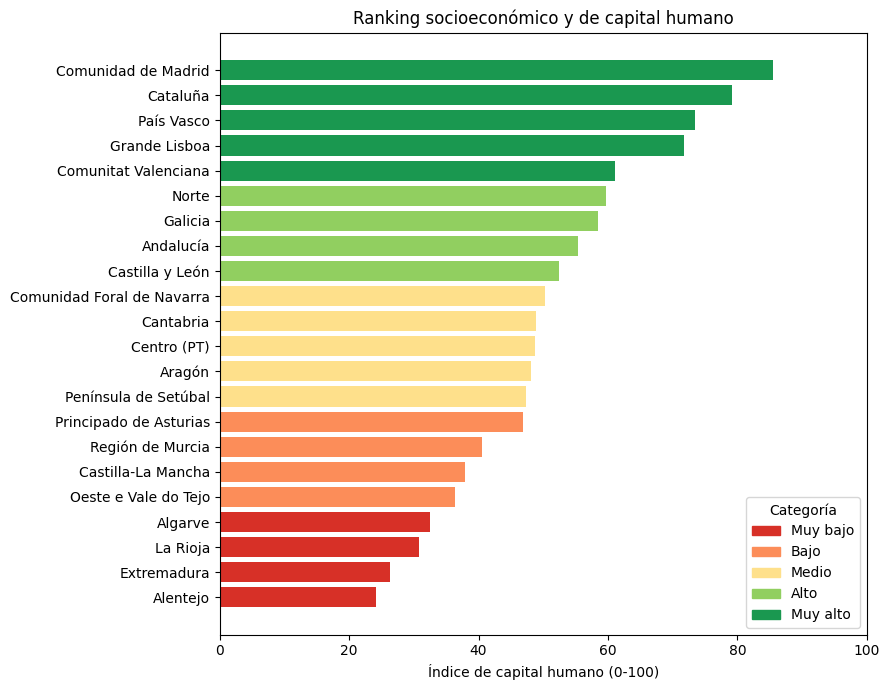

Figura 1 guardada: True


In [23]:
# ranking del índice de capital humano
from matplotlib.patches import Patch

df_figuras_08a = df_ranking_capital_humano_07a.copy()
figuras_08a = []

colores_08a = {
    "Muy bajo": "#d73027",
    "Bajo": "#fc8d59",
    "Medio": "#fee08b",
    "Alto": "#91cf60",
    "Muy alto": "#1a9850"
}
ranking_08a = df_figuras_08a.sort_values(
    "indice_capital_humano_0_100"
)
categorias_08a = (
    ranking_08a["categoria_capital_humano"]
    .astype(str)
)
plt.figure(figsize=(9, 7))
plt.barh(
    ranking_08a["nombre_territorio"],
    ranking_08a["indice_capital_humano_0_100"],
    color=categorias_08a.map(colores_08a)
)
plt.xlabel("Índice de capital humano (0-100)")
plt.title("Ranking socioeconómico y de capital humano")
plt.xlim(0, 100)
plt.legend(
    handles=[
        Patch(color=color, label=categoria)
        for categoria, color in colores_08a.items()
    ],
    title="Categoría",
    loc="lower right"
)

ruta_figura_08a_1 = (
    FIGURAS_DIR
    / "figura_08A_categorias_capital_humano.png"
)
plt.tight_layout()
plt.savefig(
    ruta_figura_08a_1,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

figuras_08a.append({
    "figura": "Ranking territorial completo",
    "ruta": str(ruta_figura_08a_1),
    "existe": ruta_figura_08a_1.exists()
})

print("Figura 1 guardada:", ruta_figura_08a_1.exists())

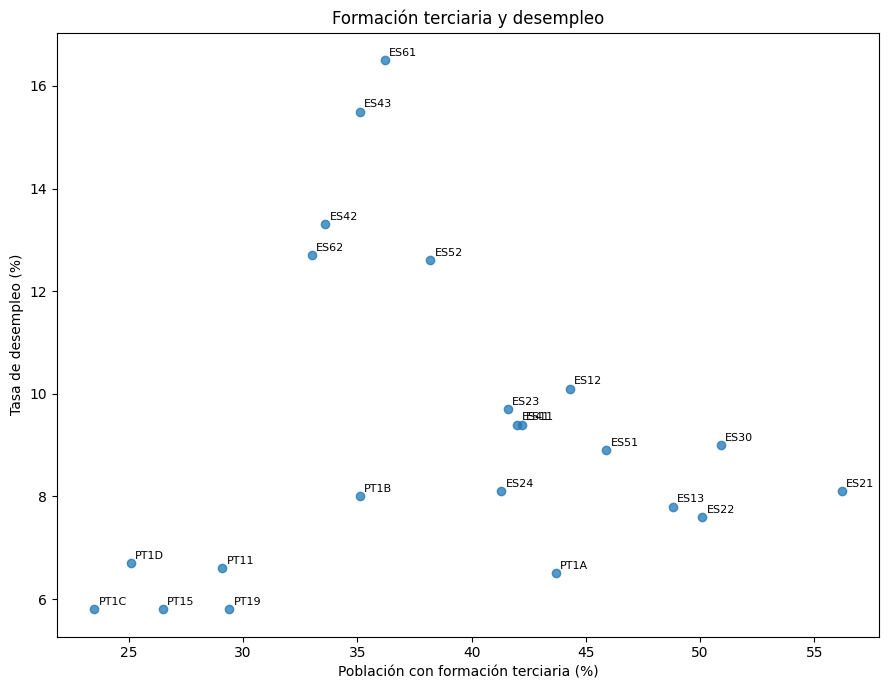

Figura 2 guardada: True


In [24]:
# formación terciaria y desempleo
plt.figure(figsize=(9, 7))
plt.scatter(
    df_figuras_08a["nivel_formativo_terciario"],
    df_figuras_08a["tasa_desempleo"],
    alpha=0.75
)

for _, fila in df_figuras_08a.iterrows():
    plt.annotate(
        fila["codigo_geo"],
        (
            fila["nivel_formativo_terciario"],
            fila["tasa_desempleo"]
        ),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Población con formación terciaria (%)")
plt.ylabel("Tasa de desempleo (%)")
plt.title("Formación terciaria y desempleo")

ruta_figura_08a_2 = (
    FIGURAS_DIR
    / "figura_08A_formacion_terciaria_vs_desempleo.png"
)

plt.tight_layout()
plt.savefig(
    ruta_figura_08a_2,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

figuras_08a.append({
    "figura": "Formación terciaria y desempleo",
    "ruta": str(ruta_figura_08a_2),
    "existe": ruta_figura_08a_2.exists()
})

print("Figura 2 guardada:", ruta_figura_08a_2.exists())

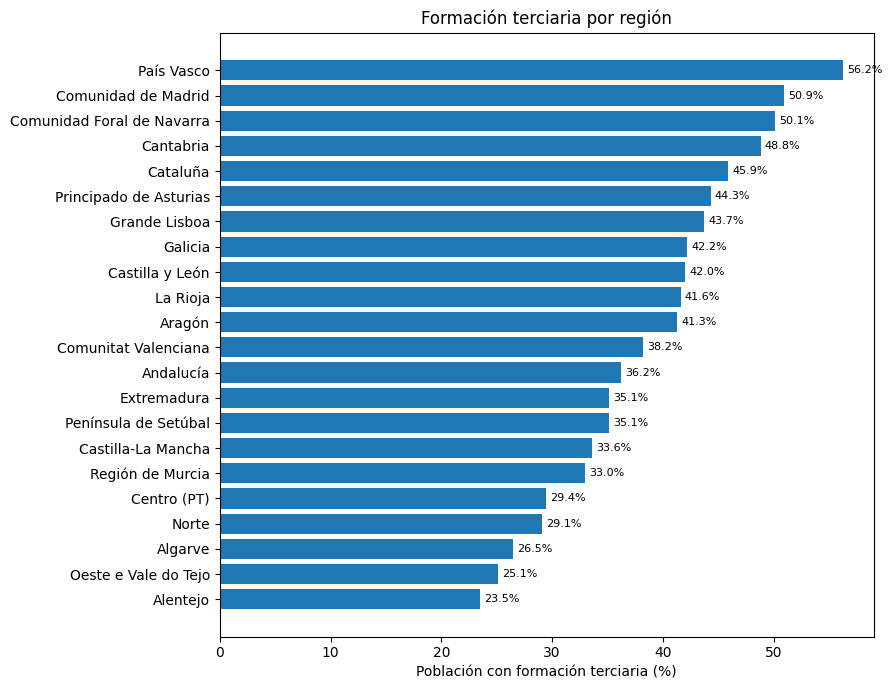

Figura 3 guardada: True


In [25]:
# formación terciaria por región
formacion_08a = df_figuras_08a.sort_values(
    "nivel_formativo_terciario"
)

plt.figure(figsize=(9, 7))

barras_08a = plt.barh(
    formacion_08a["nombre_territorio"],
    formacion_08a["nivel_formativo_terciario"]
)

plt.bar_label(
    barras_08a,
    fmt="%.1f%%",
    padding=3,
    fontsize=8
)
plt.xlabel("Población con formación terciaria (%)")
plt.title("Formación terciaria por región")

ruta_figura_08a_3 = (
    FIGURAS_DIR
    / "figura_08A_formacion_terciaria_por_region.png"
)

plt.tight_layout()
plt.savefig(
    ruta_figura_08a_3,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()

figuras_08a.append({
    "figura": "Formación terciaria por región",
    "ruta": str(ruta_figura_08a_3),
    "existe": ruta_figura_08a_3.exists()
})

print("Figura 3 guardada:", ruta_figura_08a_3.exists())

In [26]:
# cierre de las figuras
columnas_08a = [
    "ranking_capital_humano",
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "indice_capital_humano_0_100",
    "categoria_capital_humano",
    "nivel_formativo_terciario",
    "tasa_desempleo"
]
df_figuras_08a[columnas_08a].to_csv(
    TABLAS_DIR
    / "clasificacion_regional_capital_humano_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

# quitamos posibles duplicados por haber ejecutado una figura más de una vez
df_figuras_generadas_08a = (
    pd.DataFrame(figuras_08a)
    .drop_duplicates(subset="ruta", keep="last")
    .reset_index(drop=True)
)
df_figuras_generadas_08a.to_csv(
    MANIFEST_DIR / "inventario_figuras_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

estado_08a = (
    "correcto"
    if len(df_figuras_generadas_08a) == 3
    and df_figuras_generadas_08a["existe"].all()
    else "revisar"
)

pd.DataFrame([{
    "figuras_generadas": len(df_figuras_generadas_08a),
    "andorra_en_ranking": False,
    "estado": estado_08a
}]).to_csv(
    MANIFEST_DIR / "CIERRE_08A_figuras.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Figuras generadas:",
    len(df_figuras_generadas_08a)
)
print("Andorra aparece en el ranking: no")
print("Estado 08A:", estado_08a)

Figuras generadas: 3
Andorra aparece en el ranking: no
Estado 08A: correcto


### Nota de interpretación

Las categorías muestran la posición relativa de cada región dentro de las 22 unidades NUTS 2 comparables.

La formación terciaria se utiliza como una aproximación al capital humano disponible, aunque incluye estudios superiores de cualquier ámbito y no mide directamente la disponibilidad de perfiles técnicos especializados.

España y Portugal se comparan con datos de Eurostat siguiendo el mismo criterio de selección y tratamiento.

Andorra se mantiene como territorio complementario y no entra en el ranking por su distinta escala territorial y porque dispone de cuatro de los cinco indicadores.

## Dashboard del bloque socioeconómico

Creamos un dashboard HTML para resumir los principales resultados del bloque socioeconómico y de capital humano.

Incluimos el ranking de las 22 regiones comparables, los pesos utilizados, las figuras principales y una breve interpretación de los resultados.

El dashboard tiene una función descriptiva y no representa la selección final de ubicaciones. Integraremos los indicadores originales con el resto de variables del proyecto.

In [27]:
# datos para el dashboard
import html

columnas_ranking_09a = [
    "ranking_capital_humano",
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "indice_capital_humano_0_100",
    "categoria_capital_humano"
]

df_ranking_09a = (
    df_ranking_capital_humano_07a[
        columnas_ranking_09a
    ].copy()
)
df_ranking_09a[
    "indice_capital_humano_0_100"
] = (
    df_ranking_09a[
        "indice_capital_humano_0_100"
    ].round(2)
)
df_ranking_09a.columns = [
    "Posición",
    "Código",
    "Región",
    "País",
    "Índice",
    "Categoría"
]

# pesos utilizados
df_pesos_09a = df_pesos_07a.copy()
df_pesos_09a["score"] = (
    df_pesos_09a["score"]
    .str.replace("score_", "", regex=False)
    .str.replace("_", " ", regex=False)
)
df_pesos_09a.columns = [
    "Indicador",
    "Peso"
]

# datos principales
mejor_09a = df_ranking_capital_humano_07a.iloc[0]
peor_09a = df_ranking_capital_humano_07a.iloc[-1]
interpretacion_09a = (
    df_interpretacion_07b.iloc[0][
        "interpretacion"
    ]
)
territorios_totales_09a = len(
    df_modelo_socioeconomico_06a
)
regiones_comparables_09a = len(
    df_ranking_capital_humano_07a
)

print(
    "Territorios totales:",
    territorios_totales_09a
)
print(
    "Regiones comparables:",
    regiones_comparables_09a
)
print(
    "Primera región:",
    mejor_09a["nombre_territorio"]
)

Territorios totales: 23
Regiones comparables: 22
Primera región: Comunidad de Madrid


In [28]:
# figuras para el dashboard
figuras_html_09a = []

for _, figura in df_figuras_generadas_08a.iterrows():
    ruta = Path(figura["ruta"])
    if ruta.exists():
        imagen_09a = base64.b64encode(
            ruta.read_bytes()
        ).decode("utf-8")

        bloque_09a = (
            f"<section>"
            f"<h2>{html.escape(figura['figura'])}</h2>"
            f'<img src="data:image/png;base64,{imagen_09a}">'
            f"</section>"
        )

        figuras_html_09a.append(bloque_09a)
figuras_html_09a = "\n".join(figuras_html_09a)

print(
    "Figuras incorporadas al dashboard:",
    len(df_figuras_generadas_08a)
)

Figuras incorporadas al dashboard: 3


In [29]:
# contenido del dashboard
fecha_09a = datetime.now().strftime("%Y-%m-%d %H:%M")

html_dashboard_09a = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<title>Dashboard Notebook 08</title>

<style>
body {{
    font-family: Arial, sans-serif;
    max-width: 1100px;
    margin: auto;
    padding: 20px;
}}

h1 {{
    background: #263238;
    color: white;
    padding: 18px;
}}

table {{
    width: 100%;
    border-collapse: collapse;
    margin-bottom: 25px;
}}

th, td {{
    padding: 7px;
    border-bottom: 1px solid #ddd;
    text-align: left;
}}

th {{
    background: #455a64;
    color: white;
}}

img {{
    max-width: 100%;
}}

.nota {{
    background: #fff3e0;
    padding: 12px;
}}
</style>
</head>

<body>

<h1>Índice socioeconómico y de capital humano</h1>

<p>Notebook 08 · {fecha_09a}</p>

<p>
Territorios totales: <strong>{territorios_totales_09a}</strong><br>
Regiones comparables: <strong>{regiones_comparables_09a}</strong><br>
Primera posición: <strong>{html.escape(str(mejor_09a["nombre_territorio"]))}</strong><br>
Última posición: <strong>{html.escape(str(peor_09a["nombre_territorio"]))}</strong>
</p>

<h2>Ranking regional</h2>
{df_ranking_09a.to_html(index=False, border=0)}

<h2>Pesos del índice</h2>
{df_pesos_09a.to_html(index=False, border=0)}

{figuras_html_09a}

<h2>Interpretación</h2>

<p>{html.escape(str(interpretacion_09a))}</p>

<p class="nota">
Las categorías muestran diferencias entre regiones.
La formación terciaria incluye estudios superiores de cualquier ámbito.
Andorra se mantiene aparte y no entra en el ranking.
</p>

</body>
</html>
"""

print("Dashboard HTML preparado")

Dashboard HTML preparado


In [30]:
# guardamos el dashboard
ruta_dashboard_09a = (
    DASHBOARD_DIR
    / "dashboard_capital_humano_notebook_08.html"
)
ruta_dashboard_09a.write_text(
    html_dashboard_09a,
    encoding="utf-8"
)
dashboard_correcto_09a = (
    ruta_dashboard_09a.exists()
    and ruta_dashboard_09a.stat().st_size > 0
)
estado_09a = (
    "correcto"
    if dashboard_correcto_09a
    else "revisar"
)

df_inventario_dashboard_09a = pd.DataFrame([{
    "archivo": ruta_dashboard_09a.name,
    "ruta": str(ruta_dashboard_09a),
    "tamano_bytes": ruta_dashboard_09a.stat().st_size,
    "estado": estado_09a
}])

df_inventario_dashboard_09a.to_csv(
    MANIFEST_DIR / "inventario_dashboard_notebook_08.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dashboard:", ruta_dashboard_09a.name)
print(
    "Tamaño MB:",
    round(ruta_dashboard_09a.stat().st_size / 1024**2, 2)
)
print("Estado 09A:", estado_09a)

Dashboard: dashboard_capital_humano_notebook_08.html
Tamaño MB: 0.53
Estado 09A: correcto


## Salidas finales y paquete ZIP del Notebook 08

En esta sección preparamos las salidas finales del bloque socioeconómico y de capital humano.

Guardamos las tablas necesarias para su integración posterior en el Notebook 10 y reunimos los resultados del notebook en un archivo ZIP.

Las salidas mantienen dos grupos:

- las 22 regiones NUTS 2 comparables de España y Portugal;
- Andorra como territorio complementario, sin entrar en el ranking.

También conservamos el ranking y el índice de capital humano como resultados descriptivos del Notebook 08.

In [31]:
# salidas finales del bloque
scores_10a = [
    "ranking_capital_humano",
    "score_poblacion_total",
    "score_poblacion_edad_laboral",
    "score_densidad_poblacion",
    "score_tasa_desempleo",
    "score_nivel_formativo_terciario",
    "indice_capital_humano_0_1",
    "indice_capital_humano_0_100",
    "percentil_capital_humano",
    "categoria_capital_humano"
]

df_scores_10a = df_ranking_capital_humano_07a[
    ["codigo_geo", *scores_10a]
].copy()
df_capa_capital_humano_completa_10a = (
    df_modelo_socioeconomico_06a.merge(
        df_scores_10a,
        on="codigo_geo",
        how="left"
    )
)
df_capa_capital_humano_completa_10a[
    "bloque_modelo"
] = "capital_humano"
df_capa_capital_humano_completa_10a[
    "notebook_origen"
] = "Notebook 08"
df_capa_capital_humano_completa_10a[
    "descripcion_capa"
] = "Datos socioeconómicos y de capital humano."
df_capa_capital_humano_completa_10a[
    "nota_integracion"
] = ""
df_capa_capital_humano_completa_10a.loc[
    ~df_capa_capital_humano_completa_10a[
        "entra_ranking_nuts2"
    ],
    "nota_integracion"
] = "Andorra se mantiene como unidad complementaria."

# separamos NUTS 2 y Andorra
df_capa_capital_humano_nuts2_10a = (
    df_capa_capital_humano_completa_10a[
        df_capa_capital_humano_completa_10a[
            "entra_ranking_nuts2"
        ]
    ].copy()
)
df_capa_capital_humano_andorra_10a = (
    df_capa_capital_humano_completa_10a[
        ~df_capa_capital_humano_completa_10a[
            "entra_ranking_nuts2"
        ]
    ].copy()
)

print(
    "Capa completa:",
    len(df_capa_capital_humano_completa_10a)
)
print(
    "NUTS 2:",
    len(df_capa_capital_humano_nuts2_10a)
)
print(
    "Andorra:",
    len(df_capa_capital_humano_andorra_10a)
)

Capa completa: 23
NUTS 2: 22
Andorra: 1


In [32]:
# guardamos las salidas enriquecidas
ruta_capa_completa_10a = (
    PROCESSED_DIR
    / "capa_capital_humano_completa_para_modelo_master_notebook_08.csv"
)
ruta_capa_nuts2_10a = (
    PROCESSED_DIR
    / "capa_capital_humano_nuts2_comparable_para_modelo_master_notebook_08.csv"
)
ruta_capa_andorra_10a = (
    PROCESSED_DIR
    / "capa_capital_humano_andorra_complementaria_para_modelo_master_notebook_08.csv"
)

df_capa_capital_humano_completa_10a.to_csv(
    ruta_capa_completa_10a,
    index=False,
    encoding="utf-8-sig"
)
df_capa_capital_humano_nuts2_10a.to_csv(
    ruta_capa_nuts2_10a,
    index=False,
    encoding="utf-8-sig"
)
df_capa_capital_humano_andorra_10a.to_csv(
    ruta_capa_andorra_10a,
    index=False,
    encoding="utf-8-sig"
)

print("Capa completa guardada:", ruta_capa_completa_10a.exists())
print("Capa NUTS 2 guardada:", ruta_capa_nuts2_10a.exists())
print("Capa Andorra guardada:", ruta_capa_andorra_10a.exists())

Capa completa guardada: True
Capa NUTS 2 guardada: True
Capa Andorra guardada: True


## Validación final

Para terminar, comprobamos que las salidas principales del Notebook 08 se han generado correctamente.

Verificamos que hay 22 regiones NUTS 2 comparables, una fila adicional para Andorra y que el archivo usado posteriormente por el Notebook 10 mantiene la estructura que esperamos.

También comprobamos que el ZIP final se crea correctamente y contiene los resultados del notebook.


In [33]:
# validación final de las salidas
ruta_nb10_11a = (
    TABLAS_DIR
    / "modelo_socioeconomico_capital_humano_tabla_completa_notebook_08.csv"
)

columnas_nb10_11a = [
    "codigo_geo",
    "poblacion_total",
    "poblacion_edad_laboral",
    "densidad_poblacion",
    "tasa_desempleo",
    "nivel_formativo_terciario",
    "anio_poblacion_total",
    "anio_poblacion_edad_laboral",
    "anio_densidad_poblacion",
    "anio_tasa_desempleo",
    "anio_nivel_formativo_terciario"
]

df_nb10_11a = pd.read_csv(
    ruta_nb10_11a
)

figuras_11a = [
    Path(ruta)
    for ruta in df_figuras_generadas_08a["ruta"]
]

salidas_11a = [
    ruta_nb10_11a,
    ruta_capa_completa_10a,
    ruta_capa_nuts2_10a,
    ruta_capa_andorra_10a,
    TABLAS_DIR
    / "ranking_capital_humano_nuts2_comparable_notebook_08.csv",
    TABLAS_DIR
    / "pesos_indice_capital_humano_notebook_08.csv",
    Path(ruta_dashboard_09a),
    *figuras_11a
]

controles_11a = {
    "territorios_totales":
        len(df_capa_capital_humano_completa_10a) == 23,
    "territorios_ranking":
        len(df_capa_capital_humano_nuts2_10a) == 22,
    "andorra_complementaria":
        len(df_capa_capital_humano_andorra_10a) == 1,
    "codigos_unicos":
        df_capa_capital_humano_completa_10a[
            "codigo_geo"
        ].is_unique,
    "ranking_completo":
        df_capa_capital_humano_nuts2_10a[
            "indice_capital_humano_0_100"
        ].notna().all(),
    "indice_valido":
        df_capa_capital_humano_nuts2_10a[
            "indice_capital_humano_0_100"
        ].between(0, 100).all(),
    "andorra_fuera_ranking":
        not df_capa_capital_humano_andorra_10a[
            "entra_ranking_nuts2"
        ].astype(bool).any(),
    "figuras_correctas":
        len(figuras_11a) == 3,
    "salidas_creadas":
        all(
            ruta.exists()
            and ruta.stat().st_size > 0
            for ruta in salidas_11a
        ),
    "archivo_nb10":
        len(df_nb10_11a) == 23
        and df_nb10_11a["codigo_geo"].is_unique
        and all(
            columna in df_nb10_11a.columns
            for columna in columnas_nb10_11a
        )
}
estado_datos_11a = (
    "correcto"
    if all(controles_11a.values())
    else "revisar"
)

print("Territorios:", len(df_capa_capital_humano_completa_10a))
print("Ranking NUTS 2:", len(df_capa_capital_humano_nuts2_10a))
print("Andorra complementaria:", len(df_capa_capital_humano_andorra_10a))
print("Figuras:", len(figuras_11a))
print("Archivo Notebook 10:", controles_11a["archivo_nb10"])
print("Estado datos:", estado_datos_11a)

Territorios: 23
Ranking NUTS 2: 22
Andorra complementaria: 1
Figuras: 3
Archivo Notebook 10: True
Estado datos: correcto


In [34]:
# cierre y ZIP final
estado_11a = (
    "correcto"
    if all(controles_11a.values())
    else "revisar"
)
ruta_cierre_11a = (
    MANIFEST_DIR
    / "CIERRE_11A_validacion_final_notebook_08.csv"
)

pd.DataFrame([{
    **controles_11a,
    "estado": estado_11a
}]).to_csv(
    ruta_cierre_11a,
    index=False,
    encoding="utf-8-sig"
)

ruta_zip_11a = (
    Path("/kaggle/working")
    / f"{NOMBRE_BLOQUE}_FINAL.zip"
)
ruta_zip_11a.unlink(missing_ok=True)
archivos_11a = [
    ruta
    for ruta in BASE_DIR.rglob("*")
    if ruta.is_file()
]

with zipfile.ZipFile(
    ruta_zip_11a,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:

    for ruta in archivos_11a:
        archivo_zip.write(
            ruta,
            arcname=(
                Path(NOMBRE_BLOQUE)
                / ruta.relative_to(BASE_DIR)
            )
        )

with zipfile.ZipFile(ruta_zip_11a) as archivo_zip:
    zip_correcto_11a = (
        archivo_zip.testzip() is None
    )
    archivos_zip_11a = len(
        archivo_zip.namelist()
    )

if estado_11a != "correcto" or not zip_correcto_11a:
    raise RuntimeError(
        "La validación final necesita revisión."
    )

print("Archivos ZIP:", archivos_zip_11a)
print(
    "Tamaño ZIP MB:",
    round(
        ruta_zip_11a.stat().st_size / 1024**2,
        2
    )
)
print("Notebook 10: compatible")
print("Estado 11A:", estado_11a)

Archivos ZIP: 44
Tamaño ZIP MB: 0.69
Notebook 10: compatible
Estado 11A: correcto
